Задание 3:
У вас есть архив с данными по производству электроэнергии ветряными мельницами в Германии. Вам необходимо исследовать временной ряд, описать основные статистики для временного ряда, сделать вывод по временному ряду и сформировать исследовательский отчет подкрепленный соответствующими выводами.

Необходимо выбрать модель для прогноза временного ряда, объяснить почему именно была выбрана данная модель, объяснить на каком основании. Сделайте прогноз по производству электроэнергии на 1 год вперед, измерить метрику качества. Оформить исследование в jupyter notebook’e.

---

Исходные данные: **производство ветроэнергии в Германии** (`data.csv`), мощность в **МВт**, шаг **15 минут**.

Для EDA и моделирования (Части 1–3) используем **недельную** сетку — среднее `MW` за календарную неделю (`resample('W')`). Более частые сетки (час / сутки) дают избыточный шум и завышенный MAPE; недельная сглаживает суточные колебания и лучше выделяет **годовой** цикл.


---

## Часть 1. Исследование данных (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DATA_PATH = 'data.csv'
TEST_START = '2021-01-01'

def mark_lags(ax, lags, label, color='C1'):
    for i, lag in enumerate(lags):
        ax.axvline(lag, color=color, ls='--', lw=0.9, alpha=0.7,
                   label=label if i == 0 else None)


def style_lag_axis(ax, max_lag, major_step, minor_step=None):
    ax.set_xlim(0, max_lag)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    if minor_step:
        ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis='x', which='major', labelsize=9)


In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=['dt'])
raw = raw.sort_values('dt').set_index('dt')
raw.index = raw.index.tz_localize(None)

weekly = raw['MW'].resample('W').mean().dropna()
daily = raw['MW'].resample('D').mean().dropna()
hourly = raw['MW'].resample('h').mean().dropna()

print(f'Общее количество наблюдений (15 мин): {len(raw):,}')
print(f'Период: {raw.index.min()} — {raw.index.max()}')
print(f'Недельный ряд (основной): {len(weekly):,} недель')
print(f'Дневной ряд: {len(daily):,} дней')
print(f'Часовой ряд: {len(hourly):,} часов')
print(f'Общая доля нулей: {(raw["MW"] == 0).mean() * 100:.3f}%')


Общее количество наблюдений (15 мин): 385,566
Период: 2011-01-01 00:00:00 — 2021-12-30 07:45:00
Недельный ряд (основной): 575 недель
Дневной ряд: 4,017 дней
Часовой ряд: 96,381 часов
Общая доля нулей: 0.037%


#### 1.1. Общий вид ряда и описательные статистики

,дневное среднее MW
count,4017.00
mean,3183.99
std,2771.07
min,8.09
25%,1141.17
50%,2295.53
75%,4414.47
max,14491.39
median,2295.53
skew,1.45


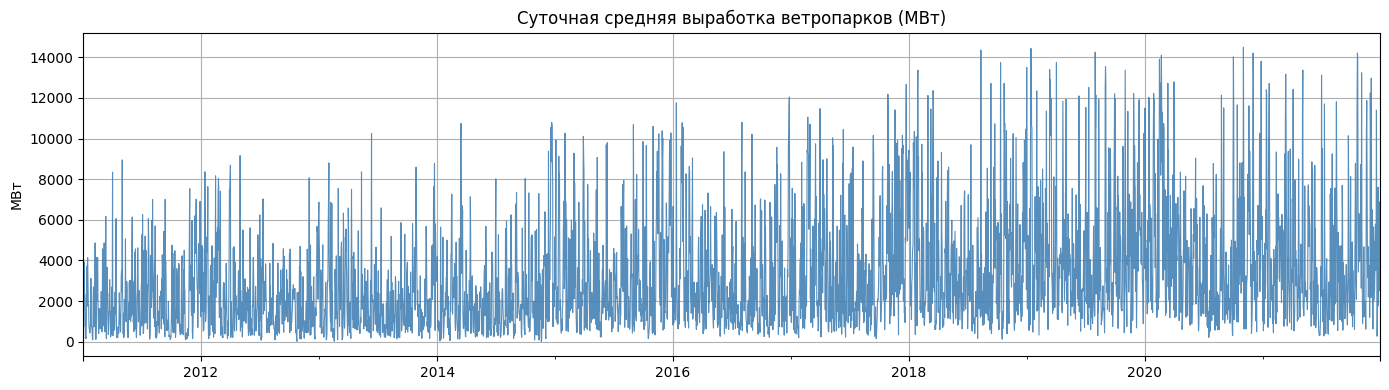

In [3]:
desc = daily.describe().to_frame('дневное среднее MW')
extra = pd.DataFrame({
    'дневное среднее MW': [daily.median(), daily.skew(), daily.kurtosis()],
}, index=['median', 'skew', 'kurtosis'])
display(pd.concat([desc, extra]).round(2))

fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, color='steelblue', linewidth=0.8, alpha=0.9)
ax.set_title('Суточная средняя выработка ветропарков (МВт)')
ax.set_ylabel('МВт')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Наблюдения:** Амплитуда и средний уровень **растут со временем** — сочетание погоды и увеличения установленной мощности в Германии.

#### 1.2. Тренд

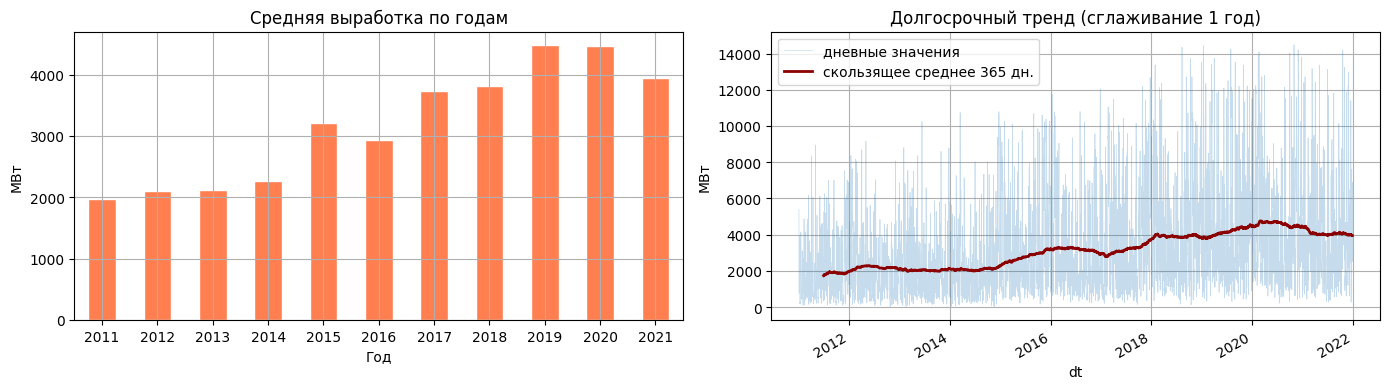

Средняя MW по годам:


,MW
dt,
2011,1978.0
2012,2108.0
2013,2112.0
2014,2257.0
2015,3213.0
2016,2931.0
2017,3734.0
2018,3816.0
2019,4476.0


In [4]:
yearly = daily.groupby(daily.index.year).mean()
monthly_mean = daily.groupby(daily.index.month).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

yearly.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Средняя выработка по годам')
axes[0].set_ylabel('МВт')
axes[0].set_xlabel('Год')
axes[0].tick_params(axis='x', rotation=0)

axes[1].plot(daily.index, daily.values, alpha=0.25, linewidth=0.5, label='дневные значения')
roll_year = daily.rolling(365, min_periods=180).mean()
roll_year.plot(ax=axes[1], color='darkred', linewidth=2, label='скользящее среднее 365 дн.')
axes[1].set_title('Долгосрочный тренд (сглаживание 1 год)')
axes[1].set_ylabel('МВт')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Средняя MW по годам:')
display(yearly.round(0).to_frame('MW'))

**Тренд — сильный.** С 2011 по 2020 средний уровень примерно **удваивается** (рост мощностей + более ветреные годы в конце декады).

#### 1.3. Сезонности (недельная сетка)

Все профили ниже построены по **недельному** ряду (средняя мощность за неделю). Суточные и часовые циклы на этой сетке **не разрешимы** — они усреднены внутри недели.


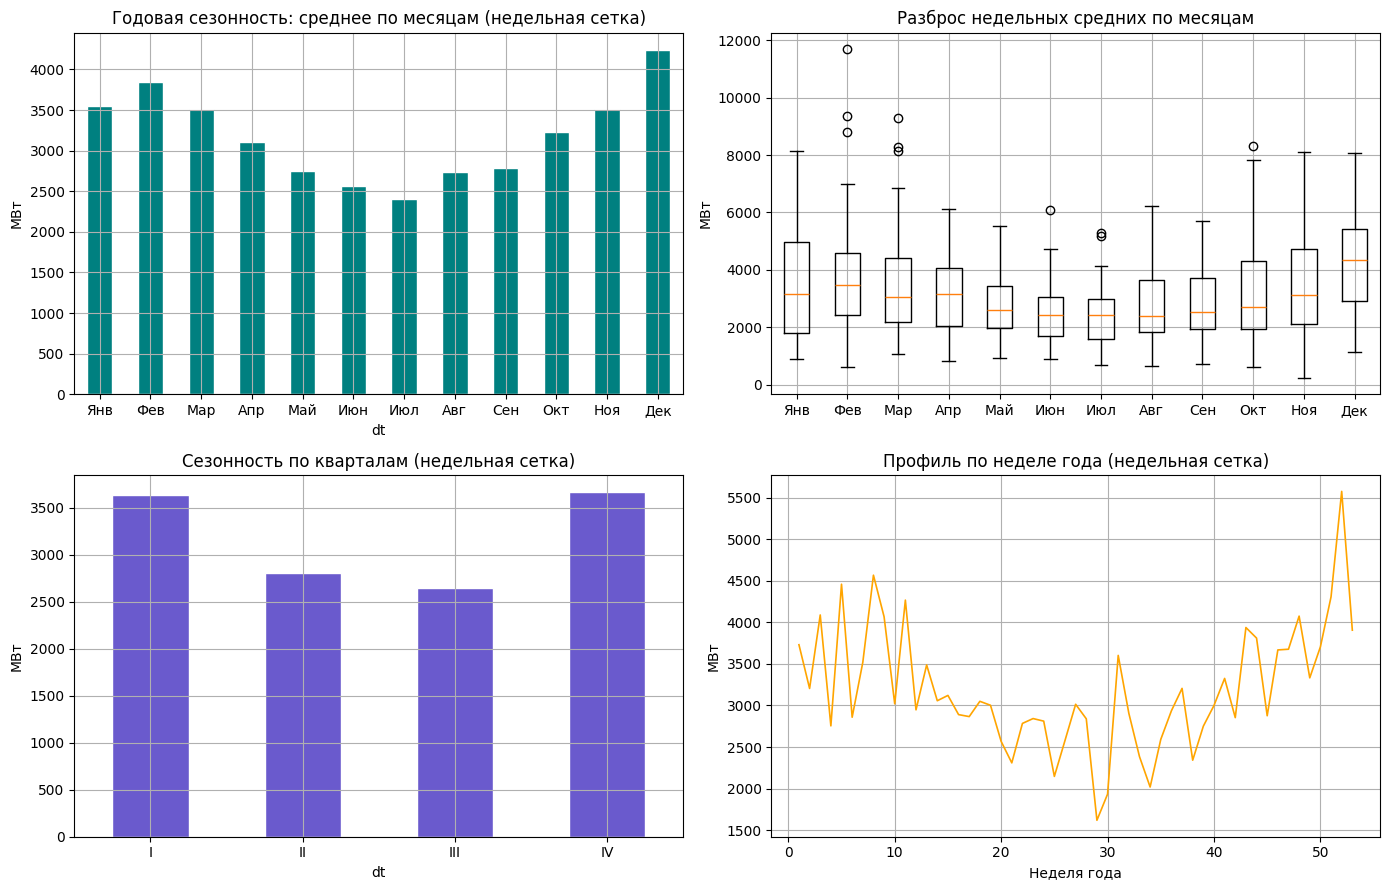

Размах сезонного профиля — месяц: 1832 МВт, квартал: 1022 МВт, неделя года (1–52): 3954 МВт


In [5]:
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
quarter_labels = ['I', 'II', 'III', 'IV']

monthly_mean_w = weekly.groupby(weekly.index.month).mean()
quarter_mean_w = weekly.groupby(weekly.index.quarter).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Годовая: профиль по месяцам (недельный ряд)
monthly_mean_w.plot(kind='bar', ax=axes[0, 0], color='teal', edgecolor='white')
axes[0, 0].set_xticklabels(month_labels, rotation=0)
axes[0, 0].set_title('Годовая сезонность: среднее по месяцам (недельная сетка)')
axes[0, 0].set_ylabel('МВт')

by_month = [weekly[weekly.index.month == m].values for m in range(1, 13)]
axes[0, 1].boxplot(by_month, labels=month_labels)
axes[0, 1].set_title('Разброс недельных средних по месяцам')
axes[0, 1].set_ylabel('МВт')

# Подгодовой цикл: кварталы
quarter_mean_w.plot(kind='bar', ax=axes[1, 0], color='slateblue', edgecolor='white')
axes[1, 0].set_xticklabels(quarter_labels, rotation=0)
axes[1, 0].set_title('Сезонность по кварталам (недельная сетка)')
axes[1, 0].set_ylabel('МВт')

# Внутригодовой профиль по номеру недели года (1–52)
woy = weekly.groupby(weekly.index.isocalendar().week.astype(int)).mean()
woy.plot(ax=axes[1, 1], color='orange', linewidth=1.2)
axes[1, 1].set_title('Профиль по неделе года (недельная сетка)')
axes[1, 1].set_xlabel('Неделя года')
axes[1, 1].set_ylabel('МВт')

plt.tight_layout()
plt.show()

amp_month = monthly_mean_w.max() - monthly_mean_w.min()
amp_quarter = quarter_mean_w.max() - quarter_mean_w.min()
amp_woy = woy.max() - woy.min()
print(
    f'Размах сезонного профиля — месяц: {amp_month:.0f} МВт, '
    f'квартал: {amp_quarter:.0f} МВт, неделя года (1–52): {amp_woy:.0f} МВт'
)


| Сезонность | Сила | Где видна на графиках §1.3 |
|------------|------|---------------------------|
| **Годовая (месяц)** | **Сильная** | Профиль и boxplot по месяцам на **недельном** ряду (зима/осень выше, лето ниже) |
| **Подгодовая (квартал)** | **Умеренная** | Столбчатый профиль по кварталам |
| **Внутригодовая (неделя года)** | **Умеренная** (шумная) | Линейный профиль по номеру недели 1–52 |
| Суточная / часовая | — | На недельной сетке **не проявляется** (усреднена) |

Коррелограммы в §1.4 строим на **том же недельном** ряду; ключевой сезонный лаг — **52 недели** (~год).


#### 1.4. Коррелограммы (недельный ряд)

- **Недельный ряд** — ACF/PACF до **104** недель (**2 года**); на оси абсцисс шаг **13** недель (квартал), доп. деления каждые **4** недели (~месяц).
- Вертикальные линии: **4**, **13**, **26**, **52** нед — ориентиры «месяц / квартал / полгода / год».


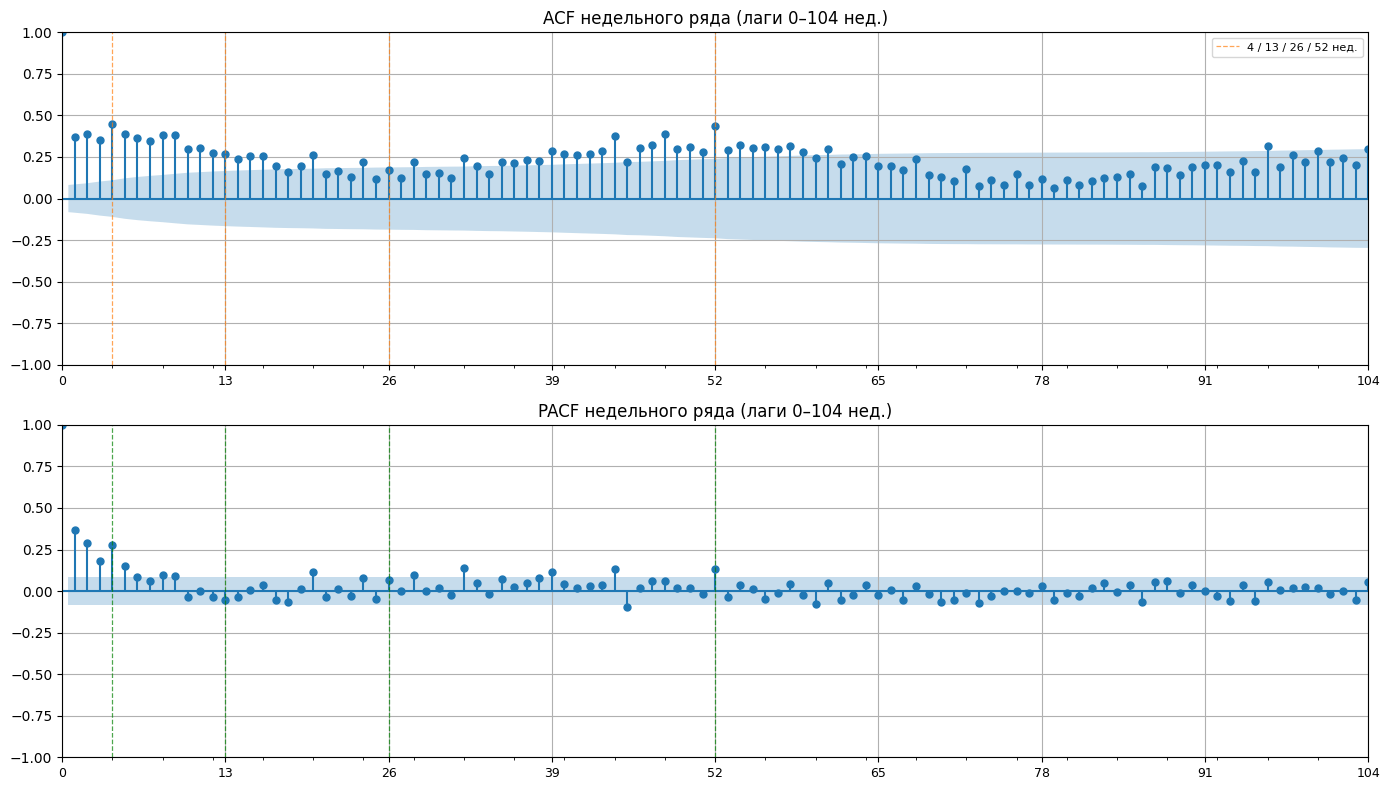

,ACF
1 нед,0.369
4 нед (~мес),0.448
13 нед (кв),0.265
26 нед (полгода),0.174
52 нед (год),0.437


In [6]:
LAGS_WEEKLY = 104  # 2 года
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(weekly, lags=LAGS_WEEKLY, ax=axes[0])
mark_lags(axes[0], [4, 13, 26, 52], '4 / 13 / 26 / 52 нед.')
axes[0].set_title(f'ACF недельного ряда (лаги 0–{LAGS_WEEKLY} нед.)')
style_lag_axis(axes[0], LAGS_WEEKLY, major_step=13, minor_step=4)
axes[0].legend(loc='upper right', fontsize=8)

plot_pacf(weekly, lags=LAGS_WEEKLY, ax=axes[1], method='ywm')
mark_lags(axes[1], [4, 13, 26, 52], '4 / 13 / 26 / 52 нед.', color='green')
axes[1].set_title(f'PACF недельного ряда (лаги 0–{LAGS_WEEKLY} нед.)')
style_lag_axis(axes[1], LAGS_WEEKLY, major_step=13, minor_step=4)
plt.tight_layout()
plt.show()

acf_w = acf(weekly, nlags=LAGS_WEEKLY, fft=True)
acf_weekly_key = pd.Series({
    '1 нед': acf_w[1],
    '4 нед (~мес)': acf_w[4],
    '13 нед (кв)': acf_w[13],
    '26 нед (полгода)': acf_w[26],
    '52 нед (год)': acf_w[52],
}).to_frame('ACF')
display(acf_weekly_key.round(3))


In [7]:
from statsmodels.tsa.stattools import pacf

pacf_w = pacf(weekly, nlags=LAGS_WEEKLY, method='ywm')
pacf_weekly_key = pd.Series({
    '1 нед': pacf_w[1],
    '4 нед (~мес)': pacf_w[4],
    '13 нед (кв)': pacf_w[13],
    '26 нед (полгода)': pacf_w[26],
    '52 нед (год)': pacf_w[52],
}).to_frame('PACF')
display(pacf_weekly_key.round(3))


,PACF
1 нед,0.369
4 нед (~мес),0.279
13 нед (кв),-0.051
26 нед (полгода),0.066
52 нед (год),0.132


**Интерпретация коррелограмм (недельный ряд, лаги в неделях):**

| Функция | Ключевые лаги (значение) | Комментарий |
|---------|--------------------------|-------------|
| **ACF** | **1** (0,37), **2–5** (0,35–0,45); **52** (0,44) | Медленное убывание + пики на ~ **4 нед** (~месяц) и **52** (год) |
| **PACF** | **1** (0,37), **2** (0,29), **4** (0,28) | Краткая память **1–4 нед** |

*Граница значимости (прибл.):* ±1,96/√n ≈ **0,082** (n ≈ 575 недель).

Вывод для модели: на недельной сетке достаточно учитывать **тренд** и **годовую** сезонность (`yearly_seasonality` в Prophet); суточную/недельную внутри недели компоненту отключаем.


#### 1.5. Выбор модели

После EDA нужна модель, которая учитывает **тренд** и **годовую** сезонность на **недельной** сетке. Ниже — почему берём **Prophet** и почему другие семейства не подходят как основная модель.

### Какие варианты не берём

**Holt–Winters (тройное экспоненциальное сглаживание)**
- Рассчитан на **один** сезонный период (`m`); для года на неделях это `m=52`, но **тренд** и смена режима в 2021 (§1.2) плохо контролируются одной формулой сглаживания.
- При n≈575 недель длинный сезон и оценка начальных состояний **нестабильны** по сравнению с гибким трендом в Prophet.

**SARIMA**
- В классической постановке — **один** сезонный лаг `m` (52 нед.), при этом ряд ещё несёт **тренд** и краткую память 1–4 нед (§1.4).
- Подбор `(p,d,q)(P,D,Q,52)` и согласование с EDA труднее, чем явная `yearly_seasonality` в Prophet; на **часовой/дневной** сетке MAPE дополнительно раздувается шумом и суточным циклом.

### Почему Prophet

Prophet выбран как **основная** модель, потому что он простым способом закрывает то, что мы уже увидели в данных:

- **Тренд** — рост средней выработки с 2011 по 2020 (§1.2); на недельном ряде тренд виден так же.
- **Годовой цикл** — профиль по месяцам, кварталам и пик ACF на **52 нед** (§1.3–1.4).
- **Суточный и часовой** циклы на недельной сетке **не выделяем** — они усреднены; в Prophet: `daily_seasonality=False`, `weekly_seasonality=False`.
- **Недельная агрегация** снижает шум и MAPE на hold-out по сравнению с часовой/дневной сеткой при той же метрике.

Модель обучается на **недельном** ряде (`freq='W'`): прогноз на **1 год** = **52 недели**. После обучения `plot_components` даёт наглядные кривые **тренда** и **годовой** компоненты — те же эффекты, что в §1.3–1.4.


---

## Часть 2. Prophet на **недельной** сетке и оценка на hold-out

Сетка — `weekly` (§1.3–1.5), `freq='W'`. Метрика качества — **MAPE (%)** на test 2021.

Подбор гиперпараметров Prophet. Hold-out: **2021**. Лучшая конфигурация → **Часть 3** (52 недели).


In [8]:
from itertools import product
from prophet import Prophet

WEEKLY_BASE = dict(daily_seasonality=False, weekly_seasonality=False)

def mape_percent(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def series_to_prophet_df(series):
    out = series.reset_index()
    out.columns = ['ds', 'y']
    return out

def prophet_train_test_split(prophet_df, test_start=TEST_START):
    test_start = pd.Timestamp(test_start)
    return (
        prophet_df[prophet_df['ds'] < test_start].copy(),
        prophet_df[prophet_df['ds'] >= test_start].copy(),
    )

def prophet_holdout_mape(train_df, test_df, prophet_params, base_prophet=WEEKLY_BASE):
    n = len(test_df)
    m = Prophet(**base_prophet, **prophet_params)
    m.fit(train_df)
    fc = m.predict(m.make_future_dataframe(periods=n, freq='W'))
    return mape_percent(test_df['y'].values, fc.tail(n)['yhat'].values), m, fc

df_weekly = series_to_prophet_df(weekly)
train_w, test_w = prophet_train_test_split(df_weekly)
print(f'Недельный ряд: train {len(train_w):,} / test {len(test_w):,} недель')


Недельный ряд: train 522 / test 53 недель


### 2.1. Подбор гиперпараметров

`seasonality_mode`, `seasonality_prior_scale`, `yearly_seasonality`, `changepoint_prior_scale`.
Критерий — **мин. MAPE (%)** на test 2021.


In [9]:
WEEKLY_TUNING_GRID = dict(
    seasonality_mode=['additive', 'multiplicative'],
    seasonality_prior_scale=[1.0, 10.0, 25.0],
    yearly_seasonality=[8, 10, 15],
    changepoint_prior_scale=[0.05, 0.5],
)
weekly_rows = []
combos = list(product(*WEEKLY_TUNING_GRID.values()))
print(f'Комбинаций: {len(combos)}')

for i, (sm, sp, ys, cps) in enumerate(combos, 1):
    params = dict(seasonality_mode=sm, seasonality_prior_scale=sp,
                  yearly_seasonality=ys, changepoint_prior_scale=cps, changepoint_range=0.9)
    mp, _, _ = prophet_holdout_mape(train_w, test_w, params)
    weekly_rows.append({**params, 'MAPE (%) test': mp})
    print(f'[{i}/{len(combos)}] ys={ys}, cps={cps} -> MAPE={mp:.2f}%')
    
weekly_tuning = pd.DataFrame(weekly_rows).sort_values('MAPE (%) test').reset_index(drop=True)
display(weekly_tuning.round(2))
best_weekly = weekly_tuning.iloc[0]
BEST_PROPHET_PARAMS = best_weekly[['seasonality_mode','seasonality_prior_scale',
    'yearly_seasonality','changepoint_prior_scale','changepoint_range']].to_dict()
display(best_weekly.to_frame('значение'))

17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing
17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing


Комбинаций: 36
[1/36] ys=8, cps=0.05 -> MAPE=48.23%


17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing
17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing


[2/36] ys=8, cps=0.5 -> MAPE=37.37%
[3/36] ys=10, cps=0.05 -> MAPE=48.82%


17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing
17:02:46 - cmdstanpy - INFO - Chain [1] start processing
17:02:46 - cmdstanpy - INFO - Chain [1] done processing


...

[33/36] ys=10, cps=0.05 -> MAPE=48.99%
[34/36] ys=10, cps=0.5 -> MAPE=41.12%


17:02:50 - cmdstanpy - INFO - Chain [1] start processing
17:02:50 - cmdstanpy - INFO - Chain [1] done processing


[35/36] ys=15, cps=0.05 -> MAPE=47.87%
[36/36] ys=15, cps=0.5 -> MAPE=38.38%


,seasonality_mode,seasonality_prior_scale,yearly_seasonality,changepoint_prior_scale,changepoint_range,MAPE (%) test
0,additive,25.0,15,0.50,0.9,34.86
1,additive,1.0,15,0.50,0.9,35.40
2,additive,10.0,15,0.50,0.9,36.02
3,additive,10.0,10,0.50,0.9,36.82
4,additive,1.0,8,0.50,0.9,37.37
5,additive,25.0,8,0.50,0.9,37.38
6,additive,25.0,10,0.50,0.9,37.67
7,multiplicative,10.0,15,0.50,0.9,37.70
8,additive,10.0,8,0.50,0.9,37.79
9,additive,1.0,10,0.50,0.9,37.84


,значение
seasonality_mode,additive
seasonality_prior_scale,25.0
yearly_seasonality,15
changepoint_prior_scale,0.5
changepoint_range,0.9
MAPE (%) test,34.863194


### 2.2. Лучшая модель на hold-out

`BEST_PROPHET_PARAMS` → Часть 3.


17:02:50 - cmdstanpy - INFO - Chain [1] start processing
17:02:50 - cmdstanpy - INFO - Chain [1] done processing


MAPE test 2021: 34.86%


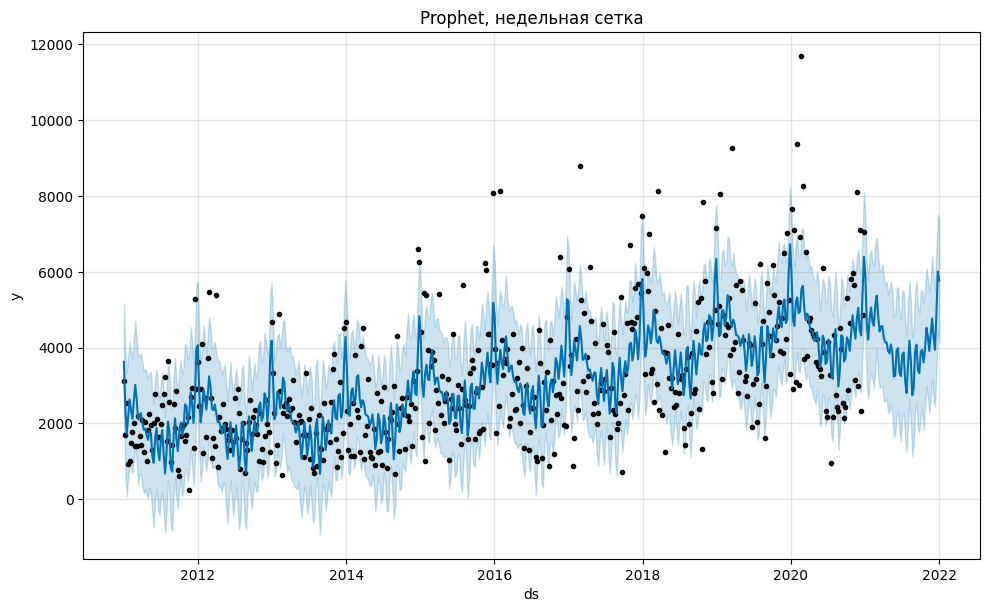

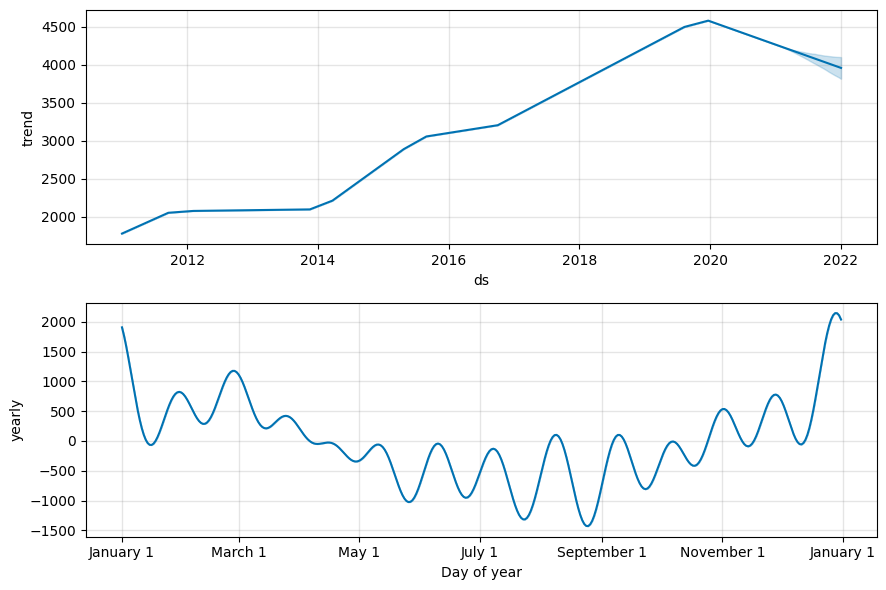

In [10]:
mape_test, model_w, fc_w = prophet_holdout_mape(train_w, test_w, BEST_PROPHET_PARAMS)
print(f'MAPE test 2021: {mape_test:.2f}%')
_ = model_w.plot(fc_w); plt.title('Prophet, недельная сетка'); plt.show()
fig = model_w.plot_components(fc_w); plt.show()


---

## Часть 3. Прогноз на 1 год вперёд (52 недели)

Переобучение на всей недельной истории с `BEST_PROPHET_PARAMS`.


17:02:50 - cmdstanpy - INFO - Chain [1] start processing
17:02:50 - cmdstanpy - INFO - Chain [1] done processing


MAPE hold-out: 34.86%
Прогноз: 2022-01-09 00:00:00 — 2023-01-01 00:00:00


,yhat,yhat_lower,yhat_upper
ds,,,
2022-01-09,4206.9,2560.2,5822.6
2022-01-16,3842.8,2227.9,5433.8
2022-01-23,4367.9,2667.7,5939.9
2022-01-30,4511.0,2915.1,6086.4
2022-02-06,4022.5,2329.4,5472.7
2022-02-13,3943.6,2339.0,5489.7
2022-02-20,4540.0,2917.0,6181.4
2022-02-27,4831.2,3209.7,6460.5
2022-03-06,4432.2,2898.9,6081.8


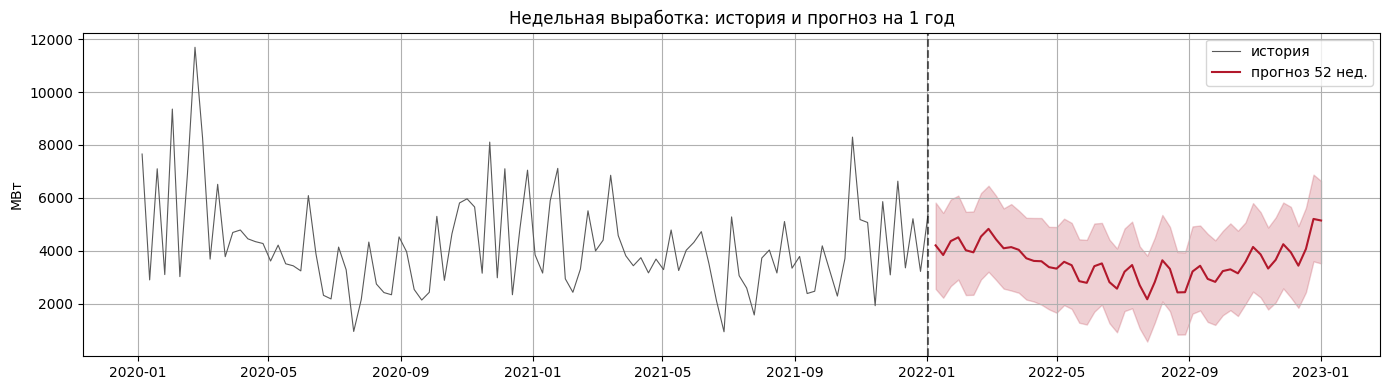

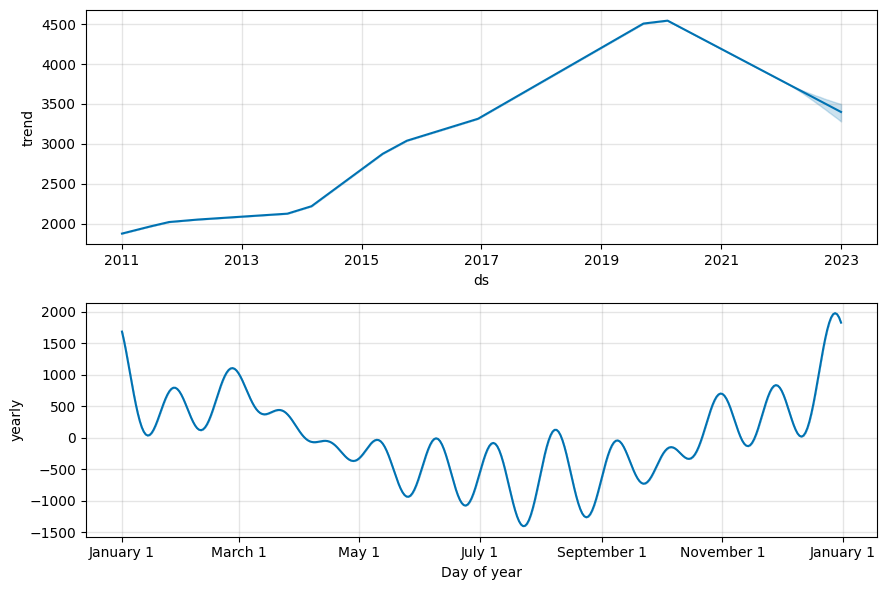

In [11]:
HORIZON_WEEKS = 52

model_final = Prophet(**WEEKLY_BASE, **BEST_PROPHET_PARAMS)
model_final.fit(df_weekly)

future = model_final.make_future_dataframe(periods=HORIZON_WEEKS, freq='W')
forecast_full = model_final.predict(future)
fc_future = forecast_full.tail(HORIZON_WEEKS).copy()
fc_future['ds'] = pd.to_datetime(fc_future['ds'])
print(f'MAPE hold-out: {mape_test:.2f}%')
print(f'Прогноз: {fc_future["ds"].min()} — {fc_future["ds"].max()}')

display(fc_future.set_index('ds')[['yhat','yhat_lower','yhat_upper']].round(1))
fig, ax = plt.subplots(figsize=(14, 4))
hist_tail = weekly[weekly.index >= weekly.index.max() - pd.Timedelta(weeks=104)]
ax.plot(hist_tail.index, hist_tail.values, color='0.35', lw=0.8, label='история')
ax.plot(fc_future['ds'], fc_future['yhat'], color='#b2182b', label='прогноз 52 нед.')
ax.fill_between(fc_future['ds'], fc_future['yhat_lower'], fc_future['yhat_upper'],
                color='#b2182b', alpha=0.2)
ax.axvline(weekly.index.max(), color='k', ls='--', alpha=0.6)
ax.set_title('Недельная выработка: история и прогноз на 1 год')
ax.set_ylabel('МВт'); ax.legend(); plt.tight_layout(); plt.show()
model_final.plot_components(forecast_full); plt.show()

### Выводы

- **Модель — Prophet (недельная сетка):** после подбора по MAPE лучшая конфигурация — `additive`, `seasonality_prior_scale=25`, `yearly_seasonality=15`, `changepoint_prior_scale=0.5`; на hold-out 2021 **MAPE ≈ 34,9%**. Варианты с жёстким трендом (`changepoint_prior_scale=0.05`) — ~**48%** MAPE; `multiplicative` — ~**39–41%**.
- **Hold-out 2021:** **MAPE ≈ 34,9%** на test (календарный год, ~53 нед.); метрика согласована с §2.1–2.2.
- **EDA → модель:** на недельном ряде выражены **тренд** и **годовая** сезонность (профиль по месяцам, пик ACF на **52 нед**); суточный цикл усреднён — в Prophet `yearly_seasonality=True`, `daily_seasonality=False`.
- **Прогноз вперёд (52 нед.):** средняя недельная выработка от ~**4207 МВт** (янв. 2022) до ~**5146 МВт** (янв. 2023); интервал 80% к концу горизонта ~**3540–6780 МВт** — неопределённость на годе заметно выше, чем на одной неделе hold-out.
